<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# **Operaciones de Aprendizaje Automático III**
# **Clase 5, GRPO desde cero**

Dos partes:

1. **Sin modelo y sin GPU.** GRPO sobre una política de juguete de cinco "tokens", en numpy, esto para ver el mecanismo entero: la ventaja relativa al grupo, los grupos que no enseñan nada, y qué hace exactamente beta.
2. **Con un modelo real y una T4.** El mismo algoritmo con trl sobre Qwen2.5-0.5B, cuarenta pasos, una recompensa de una línea.


---
## **Parte A) GRPO sin modelo**

* una política sobre cinco símbolos, solo uno da recompensa
* no hay red neuronal, no hay tokens: hay un vector de cinco logits y un softmax
* todo lo demás es igual a lo que hace GRPOTrainer

In [ ]:
import numpy as np

V, BUENO = 5, 2          # cinco simbolos posibles, el 2 es el que da recompensa


def softmax(z):
    e = np.exp(z - z.max())
    return e / e.sum()


def corrida(beta=0.0, recompensa_constante=False, pasos=300, G=8, lr=0.5, semilla=0):
    """Un entrenamiento GRPO completo sobre la politica de juguete.

    beta: contencion por KL contra la politica de referencia
    recompensa_constante: si es True, todas las respuestas valen igual
    G: tamano del grupo: cuantas muestras por paso
    """

    rng = np.random.default_rng(semilla)
    logits = np.zeros(V)
    ref = softmax(np.zeros(V)) # la politica de referencia, congelada
    historia = []

    for paso in range(pasos):
        p = softmax(logits)

        # 1. el grupo: G muestras de la politica actual
        grupo = rng.choice(V, size=G, p=p)

        # 2. la recompensa de cada una
        r = np.ones(G) if recompensa_constante else (grupo == BUENO).astype(float)

        # 3. si todas valen igual, el desvio es cero, este grupo no enseña nada
        sin_senal = r.std() < 1e-8
        if not sin_senal:
            # 4. la ventaja es relativa al promedio del grupo,no hay modelo de valor
            A = (r - r.mean()) / (r.std() + 1e-8)

            # 5. penalidad por alejarse de la referencia (el papel de beta)
            A = A - beta * (np.log(p[grupo]) - np.log(ref[grupo]))

            # 6. un paso de ascenso sobre log p(muestra), pesado por la ventaja
            grad = np.zeros(V)
            for t, a in zip(grupo, A):
                onehot = np.zeros(V)
                onehot[t] = 1.0
                grad += a * (onehot - p)
            logits += lr * grad / G

        historia.append({"paso": paso, "p_bueno": softmax(logits)[BUENO],
                         "sin_senal": sin_senal})

    p = softmax(logits)
    kl = float(np.sum(p * np.log(p / ref)))
    return p, kl, historia


p, kl, hist = corrida()
print(f"probabilidad del simbolo bueno: {p[BUENO]:.3f}")
print(f"KL contra la referencia: {kl:.3f}")
print(f"grupos sin señal: {np.mean([h['sin_senal'] for h in hist]):.0%}")

probabilidad del simbolo bueno: 0.998
KL contra la referencia: 1.591
grupos sin señal: 89%


Lo que acaba de pasar:
* la política pasó de 1/5 a casi 1 sin que nadie le dijera cuál
era el símbolo bueno
* solo comparó cada muestra con el promedio de su propio grupo
* el paso 4 es todo GRPO, PPO necesita una segunda red que estime cuánto vale cada estado, acá la línea de base es el promedio del grupo

El grupo que no enseña nada

* si las G muestras reciben la misma recompensa, el desvío es cero, la ventaja es cero y el paso no mueve nada
* en trl esto se llama frac_reward_zero_std

In [ ]:
p, kl, hist = corrida(recompensa_constante=True)
print("Con recompensa constante")
print(f"  probabilidad del bueno: {p[BUENO]:.3f} (arranco en {1/V:.3f})")
print(f"  grupos sin señal: {np.mean([h['sin_senal'] for h in hist]):.0%}")

# El caso inverso, menos obvio, una politica ya convergida tampoco produce señal
p, kl, hist = corrida()
primeros = np.mean([h["sin_senal"] for h in hist[:50]])
ultimos = np.mean([h["sin_senal"] for h in hist[-50:]])

print("Con recompensa normal")
print(f"  grupos sin señal, primeros 50 pasos: {primeros:.0%}")
print(f"  grupos sin señal, ultimos 50 pasos:  {ultimos:.0%}")

Con recompensa constante
  probabilidad del bueno: 0.200 (arranco en 0.200)
  grupos sin señal: 100%
Con recompensa normal
  grupos sin señal, primeros 50 pasos: 54%
  grupos sin señal, ultimos 50 pasos:  96%


Al final del entrenamiento casi todos los grupos quedan sin señal: la política ya elige
siempre lo mismo, así que las ocho muestras son iguales. Un frac_reward_zero_std que
sube no siempre es un problema; puede ser que ya no quede nada que aprender

**Qué hace beta**

* beta pesa cuánto se castiga alejarse de la política de referencia
* es la única variable que cambia entre los dos brazos del proyecto grande que veremos después

In [ ]:
print(f"{'beta':>6} | {'p(bueno)':>9} | {'KL':>6} | {'sin senal':>10}")
print("-" * 42)
for beta in (0.0, 0.1, 0.5, 1.0, 2.0):
    p, kl, hist = corrida(beta=beta)
    sn = np.mean([h["sin_senal"] for h in hist])
    print(f"{beta:>6} | {p[BUENO]:>9.3f} | {kl:>6.3f} | {sn:>9.0%}")

  beta |  p(bueno) |     KL |  sin senal
------------------------------------------
   0.0 |     0.998 |  1.591 |       89%
   0.1 |     0.997 |  1.584 |       89%
   0.5 |     0.992 |  1.550 |       77%
   1.0 |     0.644 |  0.465 |        3%
   2.0 |     0.399 |  0.104 |        3%


* beta no mejora la política, la frena
* con beta=2 la probabilidad del símbolo bueno se queda en 0.40 en vez de llegar a 1, y a cambio el KL baja de 1.6 a 0.1

**Esto es exactamente lo que el proyecto pone a prueba**

Si la recompensa está mal calibrada, beta alto hace que la política se aleje más despacio de la referencia, pero sigue yendo en la misma dirección

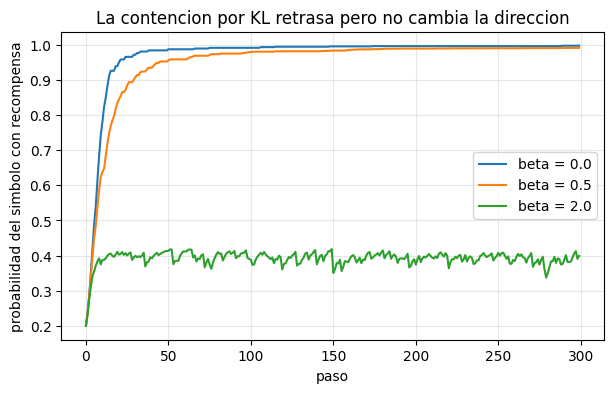

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
for beta in (0.0, 0.5, 2.0):
    _, _, hist = corrida(beta=beta)
    ax.plot([h["paso"] for h in hist], [h["p_bueno"] for h in hist], label=f"beta = {beta}")
ax.set_xlabel("paso")
ax.set_ylabel("probabilidad del simbolo con recompensa")
ax.set_title("La contencion por KL retrasa pero no cambia la direccion")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

---
## **Parte B) GRPO con modelo real**

* lo que cambia respecto de la parte 1 es solo el tamaño
* la política ahora es Qwen2.5-0.5B y las muestras son textos en vez de símbolos
* el paso 4 sigue siendo el mismo

In [ ]:
!pip install "trl>=1.14,<2" "peft>=0.14" "datasets>=3.0" "accelerate>=1.0" "torchao>=0.17"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 925.5/925.5 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 70.6 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


**el entrenamiento**

* se escribe a un archivo y se corre como script, algunas partes del
stack necesitan descriptores de archivo reales y el kernel de Jupyter no se los da
* la recompensa es de una línea: 1 si la respuesta empieza con RESPUESTA:, 0 si no
* que la condición mire el principio y no el final no es un detalle de estilo, el modelo tiene un tope de tokens, y una respuesta cortada por ese tope nunca puede cumplir una condición que mire el final
* eso vuelve la recompensa inalcanzable para buena parte de las muestras y el entrenamiento se queda sin señal
reproduce ese caso a propósito.

In [ ]:
%%writefile entrenar_grpo.py
"""GRPO sobre Qwen2.5-0.5B

Uso:  python entrenar_grpo.py [LARGO_MAXIMO] [MODO]
- MODO = inicio, la marca va al principio de la respuesta (alcanzable)
- MODO = final, la marca va al final (se vuelve imposible si el largo es pequeño)
"""

import json
import sys

from datasets import Dataset
from peft import LoraConfig
from transformers import TrainerCallback
from trl import GRPOConfig, GRPOTrainer

LARGO = int(sys.argv[1]) if len(sys.argv) > 1 else 128
MODO = sys.argv[2] if len(sys.argv) > 2 else "inicio"

MODELO = "Qwen/Qwen2.5-0.5B-Instruct"
RUTA_HISTORIAL = f"/content/historial_{MODO}_{LARGO}.jsonl"
SALIDA = f"/content/adaptador_{MODO}_{LARGO}"

MARCA = "RESPUESTA:"
CONSIGNA = {
    "inicio": f"Contesta en una o dos oraciones y empieza exactamente con {MARCA}",
    "final": f"Contesta en una o dos oraciones y termina exactamente con {MARCA}",
}[MODO]

PREGUNTAS = [
    "Por que el cielo se ve azul?", "Que es la fotosintesis?",
    "Como funciona un motor electrico?", "Que hace un compilador?",
    "Por que flota un barco de acero?", "Que es la presion atmosferica?",
    "Como se forma el granizo?", "Que es un numero primo?",
    "Por que las hojas cambian de color?", "Que es la gravedad?",
    "Como funciona una brujula?", "Que es el ADN?",
    "Por que hay mareas?", "Que es la inflacion?",
    "Como vuela un avion?", "Que es un eclipse solar?",
    "Por que el agua hierve a cien grados?", "Que es una celula?",
    "Como funciona un refrigerador?", "Que es la velocidad de la luz?",
    "Por que suena un trueno?", "Que es un algoritmo?",
    "Como se mide la temperatura?", "Que es la energia cinetica?",
    "Por que se oxida el hierro?", "Que es un virus?",
    "Como funciona el GPS?", "Que es la democracia?",
    "Por que duele el frio?", "Que es un ecosistema?",
    "Como se hace el pan?", "Que es la fotografia digital?",
]


def construir_dataset():
    # Formato conversacional: el mismo que usa el endpoint de chat al servir
    return Dataset.from_list([
        {"prompt": [{"role": "user", "content": f"{CONSIGNA}\n\n{q}"}]}
        for q in PREGUNTAS
    ])


def recompensa(completions, **kwargs):
    """1 si la respuesta lleva la marca donde corresponde, 0 si no."""
    textos = [c[0]["content"] if isinstance(c, list) else c for c in completions]
    if MODO == "inicio":
        return [1.0 if t.strip().startswith(MARCA) else 0.0 for t in textos]
    return [1.0 if t.strip().endswith(MARCA) else 0.0 for t in textos]


recompensa.__name__ = f"marca_al_{MODO}"

# Esto es un callback: una función que el trainer llama automaticamente en ciertos momentos
# on_log se ejecuta cada vez que el trainer registra métricas, como pondremos logging_steps=1
# esto ocurre en cada paso

class Historial(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return
        fila = {"paso": state.global_step}
        fila.update({k: v for k, v in logs.items() if isinstance(v, (int, float))})
        with open(RUTA_HISTORIAL, "a", encoding="utf-8") as f:
            f.write(json.dumps(fila) + "\n")


GRUPO, LOTE = 6, 2

args = GRPOConfig(
    output_dir=SALIDA,
    num_generations=GRUPO,
    # TRL pide que el lote de generacion sea multiplo del tamano de grupo,
    # porque cada prompt produce exactamente un grupo, fijarlo a mano lo vuelve
    # valido para cualquier combinacion.
    generation_batch_size=LOTE * GRUPO, # 12 respuestas por ronda de generación: 2 preguntas × 6
    per_device_train_batch_size=LOTE, # 2 respuestas por paso de gradiente (cuenta respuestas, no preguntas)
    gradient_accumulation_steps=1, # actualiza los pesos en cada paso, sin acumular gradientes
    learning_rate=3e-5, # tamaño del paso, el lr=0.5 de tu juguete
    lr_scheduler_type="constant_with_warmup", # la tasa sube al inicio y después queda fija
    warmup_steps=10, # los primeros 10 pasos sube de 0 a 3e-5, para no arrancar a golpes
    max_grad_norm=0.5, # recorta el gradiente si su norma pasa de 0.5, frena explosiones de fp16
    beta=0.02, # peso de la penalización KL contra el modelo original
    max_steps=150, # el entrenamiento dura 150 pasos de optimización
    max_completion_length=LARGO, # tokens máximos por respuesta; si se pasa, se corta
    temperature=1.0, # aleatoriedad al muestrear; da variedad al grupo
    fp16=True, # cálculos en media precisión: menos memoria, la T4 lo exige
    logging_steps=1, # registra métricas en cada paso; dispara tu callback
    save_strategy="no", # no guarda checkpoints intermedios; solo el final, a mano
    report_to=[],
    )

# aca no incluimos los modulos de MLP, incluir el MLP cuadruplicaría los parámetros entrenables
lora = LoraConfig(r=16, lora_alpha=32,
                  lora_dropout=0.05,
                  target_modules=["q_proj",
                                  "k_proj",
                                  "v_proj",
                                  "o_proj"],
                  task_type="CAUSAL_LM")

entrenador = GRPOTrainer(
    model=MODELO,
    args=args,
    reward_funcs=recompensa,
    train_dataset=construir_dataset(),
    peft_config=lora,
    callbacks=[Historial()],
)
entrenador.train()
entrenador.model.save_pretrained(f"{SALIDA}/final")
print(f"\nadaptador guardado en {SALIDA}/final")
print(f"historial en {RUTA_HISTORIAL}")

Writing entrenar_grpo.py


* cada paso (150 pasos) son doce generaciones (dos prompts por seis muestras cada uno), así que el entrenamiento ve unas mil ochocientas respuestas en total

In [ ]:
!PYTHONUNBUFFERED=1 python entrenar_grpo.py 128 inicio

config.json: 100% 659/659 [00:00<00:00, 2.20MB/s]

model.safetensors: downloading bytes:  76% 751M/988M [00:06<00:04, 47.9MB/s, 51.4MB/s  ]
model.safetensors: downloading bytes:  86% 853M/988M [00:19<00:35, 3.82MB/s, 24.0MB/s  ]
model.safetensors: downloading bytes:  86% 854M/988M [00:19<00:35, 3.80MB/s, 23.7MB/s  ]
model.safetensors: downloading bytes: 100% 854M/854M [00:23<00:00, 36.7MB/s, 23.5MB/s  ]
model.safetensors: reconstructing file: 100% 988M/988M [00:23<00:00, 42.4MB/s, 53.3MB/s  ]
Loading weights: 100% 290/290 [00:01<00:00, 285.10it/s]
generation_config.json: 100% 242/242 [00:00<00:00, 778kB/s]
tokenizer_config.json: 100% 7.30k/7.30k [00:00<00:00, 14.3MB/s]
vocab.json: 100% 2.78M/2.78M [00:00<00:00, 43.9MB/s]
merges.txt: 100% 1.67M/1.67M [00:00<00:00, 81.5MB/s]
tokenizer.json: 100% 7.03M/7.03M [00:00<00:00, 101MB/s]
{'loss': '1.78e-07', 'grad_norm': '0.0003779', 'learning_rate': '0', 'num_tokens': '2086', 'completions/mean_length': '119.3', 'completions/min_length': '67', '

**aprendió?**

In [ ]:
import json
import numpy as np

HIST = "/content/historial_inicio_128.jsonl"
filas = [json.loads(l) for l in open(HIST, encoding="utf-8")]


def promedio(clave, cuales=None):
    vals = [f[clave] for f in filas if clave in f]
    if not vals:
        return None
    if cuales == "primeros":
        vals = vals[:3]
    elif cuales == "ultimos":
        vals = vals[-3:]
    return float(np.mean(vals))


inicio = promedio("reward", "primeros")
final = promedio("reward", "ultimos")
clip = promedio("completions/clipped_ratio")
sin_senal = promedio("frac_reward_zero_std")

print(f"recompensa, primeros registros {inicio:.3f}")
print(f"recompensa, ultimos registros {final:.3f}")
print(f"respuestas cortadas, promedio {clip:.0%}")
print(f"grupos sin señal, promedio {sin_senal:.0%}")
print()

if final - inicio >= 0.15:
    print("APRENDIO: la recompensa subio y la tarea era alcanzable.")
else:
    print("NO APRENDIO")
    if clip > 0.40:
        print(f"  - se corta el {clip:.0%} de las respuestas, una recompensa que mira el FINAL del texto es inalcanzable.")
    if sin_senal > 0.80:
        print(f"  - el {sin_senal:.0%} de los grupos no tiene senal: todas las muestras valen lo mismo, la ventaja es cero y el paso no mueve nada")

recompensa, primeros registros 0.083
recompensa, ultimos registros 0.972
respuestas cortadas, promedio 64%
grupos sin señal, promedio 60%

APRENDIO: la recompensa subio y la tarea era alcanzable.


**antes y después**

el adaptador se carga sobre el modelo base

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

MODELO = "Qwen/Qwen2.5-0.5B-Instruct"
MARCA = "RESPUESTA:"
CONSIGNA = f"Contesta en una o dos oraciones y empieza exactamente con {MARCA}"
PRUEBA = ["Por que hay estaciones del año?", "Que es un semiconductor?",
          "Como se forma una perla?", "Por que el mar es salado?",
          "Que es la electricidad estatica?", "Como funciona un microondas?",
          "Por que los imanes se atraen?", "Que es la evolucion?"]

tok = AutoTokenizer.from_pretrained(MODELO)
base = AutoModelForCausalLM.from_pretrained(MODELO, dtype=torch.float16, device_map="cuda")


def responder(modelo, pregunta):
    texto = tok.apply_chat_template(
        [{"role": "user", "content": f"{CONSIGNA}\n\n{pregunta}"}],
        tokenize=False, add_generation_prompt=True)
    ids = tok(texto, return_tensors="pt").to("cuda")
    with torch.no_grad():
        salida = modelo.generate(**ids, max_new_tokens=128, do_sample=False,
                                 pad_token_id=tok.eos_token_id)
    return tok.decode(salida[0][ids.input_ids.shape[1]:], skip_special_tokens=True).strip()


antes = [responder(base, q) for q in PRUEBA]
alineado = PeftModel.from_pretrained(base, "/content/adaptador_inicio_128/final")
despues = [responder(alineado, q) for q in PRUEBA]

for q, a, d in zip(PRUEBA[:3], antes[:3], despues[:3]):
    print(f"\n{'=' * 72}\n{q}")
    print(f"\n  BASE      {a[:220]}")
    print(f"\n  ALINEADO  {d[:220]}")

cumple = lambda xs: sum(x.startswith(MARCA) for x in xs)
print(f"\n\n{'=' * 72}")
print(f"empiezan con {MARCA}   base {cumple(antes)}/{len(PRUEBA)}"
      f"   alineado {cumple(despues)}/{len(PRUEBA)}")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]


Por que hay estaciones del año?

  BASE      Respuesta: Estaciones del año se dividen en cuatro clásicos períodos: primavera, verano, otoño y invierno. Cada uno de estos períodos tiene su propia naturaleza y características únicas. Por ejemplo, la primavera es un p

  ALINEADO  RESPUESTA: Porque las estaciones del año se producen debido a la rotación de la Tierra sobre su órbita alrededor del Sol. Esta rotación hace que los puntos en el sol cambien de posición, causando cambios en la luz y la t

Que es un semiconductor?

  BASE      Un semiconductor es un material químico que se utiliza como componente fundamental en la fabricación de dispositivos electrónicos, incluyendo componentes de circuitos eléctricos, transistores, resistores y otros componen

  ALINEADO  RESPUESTA: Un semiconductor es un material que se utiliza como componente fundamental en la fabricación de dispositivos electrónicos, incluyendo componentes como transistores, resistores, fuentes de alimentación y circui

Como

---
**Escenario imposible**
* se repite el entrenamiento con dos cambios: la marca va al final de la respuesta y el tope de largo baja a 48 tokens
* la recompensa es inalcanzable, porque casi toda respuesta se corta antes de llegar al final

In [ ]:
!PYTHONUNBUFFERED=1 python entrenar_grpo.py 48 final

Loading weights: 100% 290/290 [00:00<00:00, 387.83it/s]
{'loss': '0', 'grad_norm': '0', 'learning_rate': '0', 'num_tokens': '1191', 'completions/mean_length': '45.75', 'completions/min_length': '21', 'completions/max_length': '48', 'completions/clipped_ratio': '0.9167', 'completions/mean_terminated_length': '21', 'completions/min_terminated_length': '21', 'completions/max_terminated_length': '21', 'rewards/marca_al_final/mean': '0', 'rewards/marca_al_final/std': '0', 'reward': '0', 'reward_std': '0', 'frac_reward_zero_std': '1', 'kl': '0', 'entropy': '2.532', 'clip_ratio/low_mean': '0', 'clip_ratio/high_mean': '0', 'clip_ratio/region_mean': '0', 'clip_ratio/low_min': '0', 'clip_ratio/high_max': '0', 'step_time': '5.459', 'epoch': '0.01042'}
{'loss': '1.939e-07', 'grad_norm': '0.0005315', 'learning_rate': '3e-06', 'kl': '1.286e-05', 'entropy': '2.376', 'clip_ratio/low_mean': '0', 'clip_ratio/high_mean': '0', 'clip_ratio/region_mean': '0', 'clip_ratio/low_min': '0', 'clip_ratio/high_max'

In [ ]:
import json

import matplotlib.pyplot as plt
import numpy as np

CORRIDAS = [
    ("/content/historial_inicio_128.jsonl", "marca al inicio, tope 128", "#2a78d6"),
    ("/content/historial_final_48.jsonl", "marca al final, tope 48", "#c2342f"),
]

print(f"{'corrida':<28} | {'recompensa final':>17} | {'cortadas':>9} | {'sin senal':>10}")
print("-" * 76)
for ruta, etiqueta, _ in CORRIDAS:
    try:
        f = [json.loads(l) for l in open(ruta, encoding="utf-8")]
    except FileNotFoundError:
        continue
    r = [x["reward"] for x in f if "reward" in x]
    c = [x["completions/clipped_ratio"] for x in f if "completions/clipped_ratio" in x]
    s = [x["frac_reward_zero_std"] for x in f if "frac_reward_zero_std" in x]
    print(f"{etiqueta:<28} | {np.mean(r[-3:]):>17.3f} | {np.mean(c):>8.0%} | {np.mean(s):>9.0%}")

corrida                      |  recompensa final |  cortadas |  sin senal
----------------------------------------------------------------------------
marca al inicio, tope 128    |             0.972 |      64% |       60%
marca al final, tope 48      |             0.000 |      93% |      100%


* en la corrida imposible la recompensa queda plana cerca de cero
* las respuestas cortadas se disparan y los grupos sin señal se van a casi el cien por ciento
* ninguna de esas tres cosas lanza un error: el script termina bien,
guarda su adaptador y reporta su train_loss

**Conclusiones**

- La ventaja de GRPO es relativa al grupo, esta es la diferencia con PPO
- Un grupo donde todas las respuestas valen igual no enseña nada
- beta retrasa el alejamiento de la referencia, no cambia hacia dónde va la política
- una recompensa puede ser inalcanzable por su interacción con otro parámetro, y el entrenamiento igual corre, termina y guarda.